## **5. Análisis cualitativo de resultados**

**Objetivo:** interpretar el comportamiento del modelo ganador (**B1 - PCA + Similitud del Coseno**) mediante casos de uso concretos. El análisis se articula en dos bloques:

1. **Canciones del catálogo:** tres canciones con perfiles acústicos contrastados. Para cada una se examinan las recomendaciones desde dos perspectivas: la métrica (distancias coseno y valores de características) y la apreciación personal.
2. **Canciones fuera de vocabulario (OOV):** se evalúa el comportamiento del módulo de extracción OOV desarrollado en el Notebook 3, tanto con una canción del catálogo (para poder comparar contra la referencia real) como con una canción nueva.

**Pasos clave:**
1. Imports y carga de artefactos
2. Definición de funciones de análisis
3. Análisis de canciones del catálogo
4. Análisis comparativo transversal
5. Análisis del módulo OOV

### **5.1 Imports y carga de artefactos**

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from itertools import combinations

from sklearn.metrics.pairwise import cosine_distances

# Configuración visual
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42

os.makedirs('figuras/Cualitativo', exist_ok=True)

# Carga de artefactos del modelo B1
meta        = joblib.load('models/catalogo_metadata.joblib')   # (174582, 4)
X_pca       = joblib.load('models/catalogo_pca.joblib')        # (174582, 15)
pca         = joblib.load('models/modelo_pca.joblib')          # transformador PCA
scaler      = joblib.load('models/modelo_scaler.joblib')       # MinMaxScaler
encoder     = joblib.load('models/modelo_encoder.joblib')      # OneHotEncoder
num_cols    = joblib.load('models/config_num_cols.joblib')
cat_cols    = joblib.load('models/config_cat_cols.joblib')

# Dataset procesado (para acceder a los valores originales de características)
df = pd.read_csv('data/dataset_procesado.csv')

print(f"Catálogo cargado: {len(meta):,} canciones | {X_pca.shape[1]} componentes PCA")
print(f"Características numéricas ({len(num_cols)}): {num_cols}")
print(f"Características categóricas ({len(cat_cols)}): {cat_cols}")

Catálogo cargado: 174,582 canciones | 15 componentes PCA
Características numéricas (10): ['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']
Características categóricas (2): ['key', 'mode']


### **5.2 Funciones de análisis**

Se definen las funciones reutilizables que se aplicarán a lo largo de todo el análisis:

- **`recomendar`**: localiza una canción en el catálogo por su `track_id` único y devuelve sus 5 recomendaciones más cercanas según distancia coseno en el espacio PCA, junto con los valores de características.
- **`calcular_cohesion_diversidad`**: calcula la cohesión y diversidad del vecindario de una canción concreta.
- **`plot_radar`**: genera un gráfico radar comparando las características acústicas de la canción de entrada con sus recomendaciones.
- **`plot_similitudes`**: genera un gráfico de barras horizontales con las distancias coseno de cada recomendación.

In [2]:
def recomendar(track_id, k=5):
    """
    Localiza una canción en el catálogo por su track_id único y devuelve
    sus K recomendaciones según distancia coseno en el espacio PCA (modelo B1).
    ----------
    Parámetros:
    track_id : str - identificador único de Spotify de la canción de entrada.
    k        : int - número de recomendaciones a devolver (por defecto 5).
    ----------
    Devuelve:
    entrada_meta  : Series - metadatos de la canción de entrada.
    entrada_feats : Series - valores de características de la canción de entrada.
    df_recs       : DataFrame - recomendaciones con metadatos, similitud y características.
    idx_entrada   : int - índice en el catálogo (para excluirla del cálculo).
    """
    mask = meta['track_id'] == track_id
    if not mask.any():
        raise ValueError(f"track_id no encontrado en el catálogo: {track_id}")

    idx = meta[mask].index[0]
    entrada_meta  = meta.loc[idx]
    entrada_feats = df.loc[idx, num_cols]

    # Distancias coseno en el espacio PCA
    vec   = X_pca[idx].reshape(1, -1)
    dists = cosine_distances(vec, X_pca)[0]
    dists[idx] = np.inf                         # excluir la propia canción
    top_idx = np.argsort(dists)[:k]

    rows = []
    for rank, ti in enumerate(top_idx, start=1):
        rows.append({
            'rank'         : rank,
            'track_name'   : meta.iloc[ti]['track_name'],
            'artist_name'  : meta.iloc[ti]['artist_name'],
            'popularity'   : meta.iloc[ti]['popularity'],
            'cosine_sim'   : round(1 - dists[ti], 6),
            'cosine_dist'  : round(dists[ti], 6),
            **{col: round(df.iloc[ti][col], 4) for col in num_cols}
        })

    return entrada_meta, entrada_feats, pd.DataFrame(rows), idx


In [3]:
def calcular_cohesion_diversidad(idx):
    """
    Calcula la cohesión y diversidad del vecindario de una canción
    usando exactamente la misma metodología que en el Notebook 4.
    ----------
    cohesión   : distancia coseno media entre la entrada y sus 5 recomendaciones (↓ mejor).
    diversidad : distancia coseno media entre todos los pares de recomendaciones (↑ mejor).
    """
    vec   = X_pca[idx].reshape(1, -1)
    dists = cosine_distances(vec, X_pca)[0]
    dists_copia = dists.copy()
    dists_copia[idx] = np.inf
    top_idx  = np.argsort(dists_copia)[:5]
    rec_vecs = X_pca[top_idx]

    cohesion  = float(np.mean(cosine_distances(vec, rec_vecs)[0]))
    pares     = list(combinations(range(5), 2))
    diversidad = float(np.mean([
        cosine_distances(rec_vecs[[i]], rec_vecs[[j]])[0][0]
        for i, j in pares
    ]))
    return cohesion, diversidad

In [4]:
# Features para los gráficos radar (las más interpretables musicalmente)
RADAR_FEATURES = ['acousticness', 'danceability', 'energy', 'liveness', 'loudness', 'valence']
RADAR_LABELS   = ['Acousticness', 'Danceability', 'Energy', 'Liveness', 'Loudness', 'Valence']

def plot_radar(entrada_feats, df_recs, titulo, savepath=None):
    """
    Gráfico radar con las características acústicas de la canción de entrada
    (línea azul gruesa) y sus 5 recomendaciones (líneas grises finas).
    """
    N = len(RADAR_FEATURES)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    # Recomendaciones en gris
    for _, row in df_recs.iterrows():
        values = [row[f] for f in RADAR_FEATURES] + [row[RADAR_FEATURES[0]]]
        ax.plot(angles, values, color='#aaaaaa', linewidth=1, alpha=0.6)
        ax.fill(angles, values, color='#aaaaaa', alpha=0.05)

    # Canción de entrada en azul
    vals_entrada = [entrada_feats[f] for f in RADAR_FEATURES] + [entrada_feats[RADAR_FEATURES[0]]]
    ax.plot(angles, vals_entrada, color='steelblue', linewidth=2.5, label='Canción de entrada')
    ax.fill(angles, vals_entrada, color='steelblue', alpha=0.15)

    ax.set_thetagrids(np.degrees(angles[:-1]), RADAR_LABELS, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(titulo, size=12, fontweight='bold', pad=18)

    entrada_patch = mpatches.Patch(color='steelblue', label='Canción de entrada')
    recs_patch    = mpatches.Patch(color='#aaaaaa',   label='Recomendaciones (×5)')
    ax.legend(handles=[entrada_patch, recs_patch],
              loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

In [5]:
def plot_similitudes(df_recs, titulo, savepath=None):
    """
    Gráfico de barras horizontales con la similitud coseno de cada recomendación.
    Barras más largas = mayor similitud (más parecida a la canción de entrada).
    El eje X arranca justo por debajo del mínimo para amplificar las diferencias,
    que de otro modo serían invisibles dado el rango estrecho (0.9997 – 0.9999).
    """
    labels = [f"{r['rank']}. {r['track_name']} - {r['artist_name']}"
              for _, r in df_recs.iterrows()]
    sims  = df_recs['cosine_sim'].values   # ya calculadas por recomendar()
    dists = df_recs['cosine_dist'].values

    rango = sims.max() - sims.min()
    # Si todas las similitudes son casi iguales, usar margen fijo
    margen = rango * 2 if rango > 1e-7 else 0.0001
    x_min  = max(0.998, sims.min() - margen)
    x_max  = min(1.0, sims.max() + margen * 4)  # nunca superar 1.0

    colores = plt.cm.Blues(np.linspace(0.45, 0.85, len(sims)))

    fig, ax = plt.subplots(figsize=(10, 4))
    # barh con left=x_min: la barra empieza en x_min y llega hasta sims[i]
    bars = ax.barh(labels[::-1], sims[::-1] - x_min,
                   left=x_min, color=colores, edgecolor='white', height=0.55)

    for bar, sim, dist in zip(bars, sims[::-1], dists[::-1]):
        ax.text(x_min + bar.get_width() + margen * 0.3,
                bar.get_y() + bar.get_height() / 2,
                f'sim={sim:.6f}  |  dist={dist:.6f}',
                va='center', fontsize=9, color='#333333')

    ax.set_xlabel('Similitud coseno (↑ más similar)', fontsize=11)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlim(x_min, x_max)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.5f'))
    sns.despine()
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

### **5.3 Análisis de canciones del catálogo**

Se han seleccionado tres canciones con **perfiles acústicos bien diferenciados** entre sí y ampliamente conocidas por cualquier oyente, lo que facilita la valoración cualitativa de las recomendaciones:

|   | Canción | Artista | Perfil acústico |
|---|---------|---------|-----------------|
| 1 | *Smells Like Teen Spirit* | Nirvana | Grunge: energía máxima, sin acústica, distorsión |
| 2 | *The Climb* | Miley Cyrus | Pop emocional: baja danceability, energía media, melancólica |
| 3 | *Rewrite the Stars* | Zac Efron | Pop cinematográfico: bailable, baja valencia, oscura |

Para cada caso se analiza: (1) la tabla de recomendaciones con distancias coseno y valores de características, (2) el gráfico radar comparativo y (3) la interpretación cualitativa de los resultados.

#### **Caso 1 - Smells Like Teen Spirit (Nirvana)**

In [6]:
# track_id de Smells Like Teen Spirit - Nirvana
meta_1, feats_1, recs_1, idx_1 = recomendar('5ghIJDpPoe3CfHMGu71E6T')

print(f"Canción de entrada: {meta_1['track_name']} - {meta_1['artist_name']} (popularidad: {meta_1['popularity']})")

# Tabla de características de la entrada
print(f"\nCaracterísticas acústicas de la entrada:")
print(feats_1[['acousticness','danceability','energy','liveness','loudness','speechiness','tempo','valence']].to_frame().T.to_string(index=False))

# Tabla de recomendaciones
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
print(f"\nRecomendaciones:")
display(recs_1[['rank','track_name','artist_name','popularity',
                'cosine_sim','cosine_dist',
                'acousticness','danceability','energy','loudness','liveness','valence','tempo']])

Canción de entrada: Smells Like Teen Spirit - Nirvana (popularidad: 72)

Características acústicas de la entrada:
 acousticness  danceability   energy  liveness  loudness  speechiness    tempo  valence
     0.000029      0.492489 0.906905  0.096261  0.852867     0.046147 0.406523    0.728

Recomendaciones:


,rank,track_name,artist_name,popularity,cosine_sim,cosine_dist,acousticness,danceability,energy,loudness,liveness,valence,tempo
0,1,Don't Run Away,Masked Intruder,27,0.999880,0.000120,0.0000,0.4152,0.9469,0.8498,0.0836,0.694,0.3371
1,2,Alone Together,Dan + Shay,65,0.999874,0.000126,0.0053,0.5193,0.8709,0.8490,0.0778,0.665,0.7039
2,3,Still Swingin',Papa Roach,51,0.999822,0.000178,0.0001,0.5579,0.8889,0.8209,0.1266,0.680,0.5112
3,4,Fireworks,Animal Collective,45,0.999739,0.000261,0.0179,0.5258,0.9119,0.8469,0.0795,0.741,0.6368
4,5,Blood on Your Tongue,Direct Hit!,30,0.999735,0.000265,0.0001,0.4217,0.9429,0.8424,0.1245,0.722,0.6804


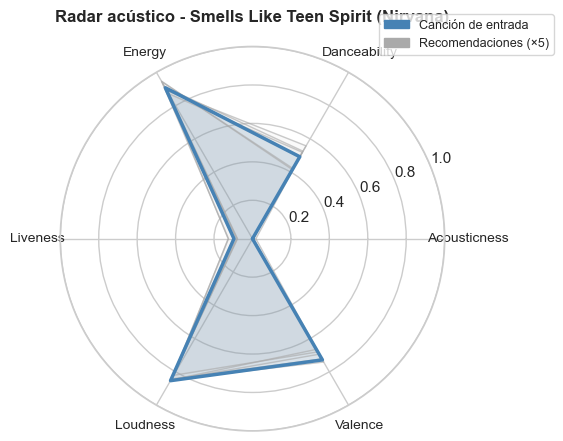

In [7]:
plot_radar(
    feats_1, recs_1,
    titulo='Radar acústico - Smells Like Teen Spirit (Nirvana)',
    savepath='figuras/Cualitativo/radar_smells_like_teen_spirit.png'
)

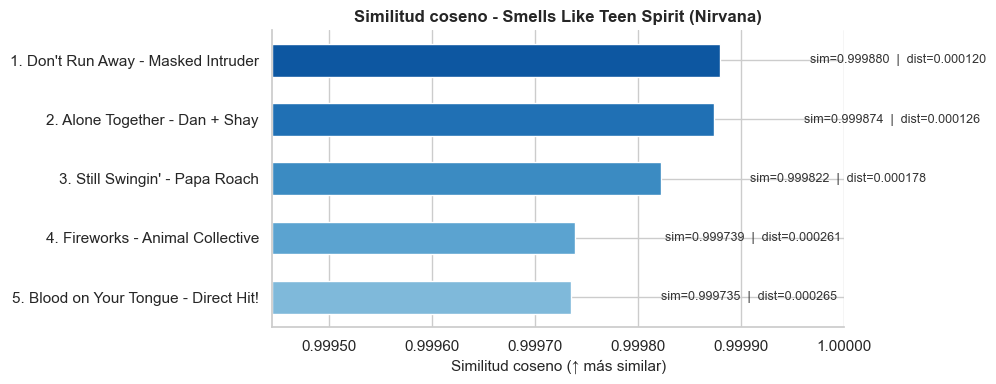

In [8]:
plot_similitudes(
    recs_1,
    titulo='Similitud coseno - Smells Like Teen Spirit (Nirvana)',
    savepath='figuras/Cualitativo/dist_smells_like_teen_spirit.png'
)

**Interpretación:**

Las cinco recomendaciones presentan similitudes coseno entre **0.999735 y 0.999880**, con distancias en el rango **0.000120–0.000265**, muy por debajo de la cohesión media global del modelo (0.0014). Esto indica que *Smells Like Teen Spirit* ocupa una zona del catálogo densamente poblada.

Comparando las características de la entrada con las recomendaciones, las dimensiones más determinantes son:

- **energy**: la canción de entrada tiene `energy = 0.907`; las cinco recomendaciones oscilan entre 0.871 y 0.947, con una desviación máxima de ±0.036 respecto a la media.
- **acousticness**: prácticamente nula en la entrada (`0.000`) y en todas las recomendaciones (< 0.018).
- **loudness**: estrecho rango en el vecindario (0.821–0.850 frente al 0.853 de la entrada).

Estas tres características son las que anclan el vecindario y las que el radar refleja con mayor claridad: el área sombreada de las recomendaciones se superpone casi exactamente con la de la canción de entrada en esos tres ejes. La `danceability` presenta algo más de variación (0.415–0.558), lo que explica la mayor dispersión del vecindario en esa dimensión.

Desde mi apreciación personal, considero que las recomendaciones son **parcialmente coherentes**. **Don't Run Away (Masked Intruder)** y **Still Swingin' (Papa Roach)** sí se parecen: son punk melódico y post-grunge respectivamente, géneros directamente relacionados con Nirvana en energía y carácter. **Blood on Your Tongue (Direct Hit!)** es hardcore punk, también en la misma línea. Sin embargo, **Alone Together (Dan + Shay)** es country pop y **Fireworks (Animal Collective)** es indie experimental: ninguna de las dos suena como Nirvana, aunque métricamente sus valores de `energy` y `loudness` sean similares. Este resultado muestra con claridad que el modelo opera sobre descriptores acústicos y no sobre género musical: dos canciones con energía y loudness similares resultan vecinas en el espacio PCA aunque suenen completamente distintas para un oyente.

#### **Caso 2 - The Climb (Miley Cyrus)**

In [9]:
# track_id de The Climb - Miley Cyrus
meta_2, feats_2, recs_2, idx_2 = recomendar('0V8FYVlBFuXXTIvRnMbZyS')

print(f"Canción de entrada: {meta_2['track_name']} - {meta_2['artist_name']} (popularidad: {meta_2['popularity']})")

print(f"\nCaracterísticas acústicas de la entrada:")
print(feats_2[['acousticness','danceability','energy','liveness','loudness','speechiness','tempo','valence']].to_frame().T.to_string(index=False))

print(f"\nRecomendaciones:")
display(recs_2[['rank','track_name','artist_name','popularity',
                'cosine_sim','cosine_dist',
                'acousticness','danceability','energy','loudness','liveness','valence','tempo']])

Canción de entrada: The Climb - Miley Cyrus (popularidad: 70)

Características acústicas de la entrada:
 acousticness  danceability  energy  liveness  loudness  speechiness    tempo  valence
     0.083735        0.2897 0.58858  0.095251  0.815751     0.012066 0.614966    0.329

Recomendaciones:


,rank,track_name,artist_name,popularity,cosine_sim,cosine_dist,acousticness,danceability,energy,loudness,liveness,valence,tempo
0,1,Love Never Fails,Israel Houghton,30,0.999916,0.000084,0.1014,0.3648,0.6156,0.8102,0.0748,0.314,0.6090
1,2,Always,Bon Jovi,74,0.999812,0.000188,0.1175,0.3498,0.6597,0.8345,0.0688,0.327,0.5195
2,3,Changed,Rascal Flatts,47,0.999747,0.000253,0.0787,0.4142,0.5596,0.8143,0.0899,0.291,0.5178
3,4,I Almost Do,Taylor Swift,54,0.999720,0.000280,0.0204,0.5461,0.4845,0.8054,0.1629,0.220,0.5439
4,5,Radar Love - Original Single Edit 1973,Golden Earring,53,0.999713,0.000287,0.0118,0.4678,0.5826,0.6734,0.1175,0.249,0.3352


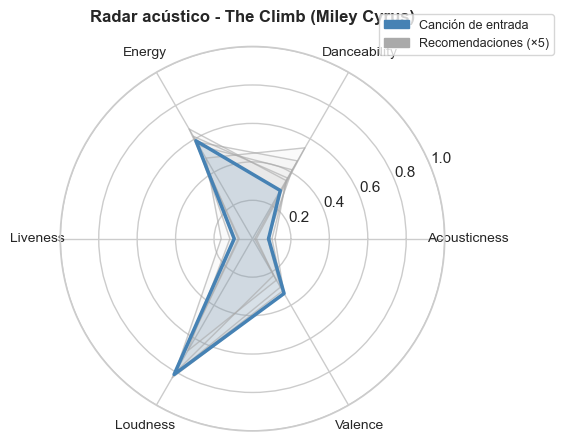

In [10]:
plot_radar(
    feats_2, recs_2,
    titulo='Radar acústico - The Climb (Miley Cyrus)',
    savepath='figuras/Cualitativo/radar_the_climb.png'
)

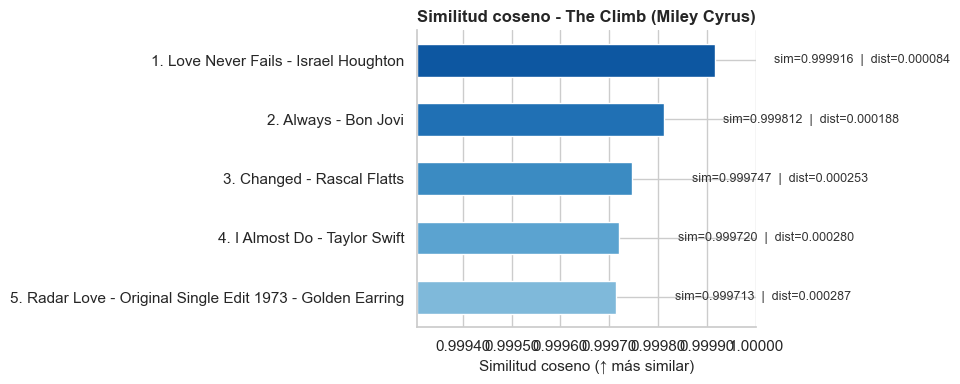

In [11]:
plot_similitudes(
    recs_2,
    titulo='Similitud coseno - The Climb (Miley Cyrus)',
    savepath='figuras/Cualitativo/dist_the_climb.png'
)

**Interpretación:**

Las similitudes coseno oscilan entre **0.999713 y 0.999916**, con distancias en el rango **0.000084–0.000287**. Con una cohesión de vecindario de 0.000218, este caso es el más ajustado de los tres, lo que refleja que el perfil de *The Climb* está bien representado en el catálogo.

Las características que definen el vecindario son:

- **energy**: la entrada tiene `energy = 0.589`; el vecindario oscila entre 0.485 y 0.660, siempre en la zona de energía media-baja.
- **danceability**: `0.290` en la entrada; las recomendaciones van de 0.350 a 0.546, siendo este el eje donde el radar muestra más separación entre la entrada y las recomendaciones.
- **valence**: `0.329` en la entrada; el vecindario va de 0.220 a 0.327, consistentemente en la zona melancólica.
- **acousticness**: baja pero presente en todas las canciones (0.012–0.199), a diferencia del caso anterior donde era nula.

La única divergencia notable en el radar aparece en `liveness`, donde *I Almost Do* de Taylor Swift (0.163) se aleja algo del resto del vecindario (entrada: 0.095).

Desde mi apreciación personal, estas recomendaciones me parecen **las más acertadas de los tres casos**. **Always (Bon Jovi)** es una power ballad emocional que, aunque de rock, comparte el mismo carácter inspirador y la estructura de subida emocional que *The Climb*. **I Almost Do (Taylor Swift)** es una balada introspectiva con piano, musicalmente muy similar en sensación. **Love Never Fails (Israel Houghton)** y **Changed (Rascal Flatts)** son temas inspiracionales de gospel y country que transmiten la misma energía moderada y carga emocional. **Radar Love (Golden Earring)** es la más sorprendente: es rock clásico de los 70, pero al escucharla se entiende la conexión métrica (tempo moderado, energía media), aunque musicalmente yo no las asociaría. En general, el modelo ha capturado bien el perfil de balada emotiva de la canción.

#### **Caso 3 - Rewrite the Stars (Zac Efron)**

In [12]:
# track_id de Rewrite the Stars - Zac Efron
meta_3, feats_3, recs_3, idx_3 = recomendar('65fpYBrI8o2cfrwf2US4gq')

print(f"Canción de entrada: {meta_3['track_name']} - {meta_3['artist_name']} (popularidad: {meta_3['popularity']})")

print(f"\nCaracterísticas acústicas de la entrada:")
print(feats_3[['acousticness','danceability','energy','liveness','loudness','speechiness','tempo','valence']].to_frame().T.to_string(index=False))

print(f"\nRecomendaciones:")
display(recs_3[['rank','track_name','artist_name','popularity',
                'cosine_sim','cosine_dist',
                'acousticness','danceability','energy','loudness','liveness','valence','tempo']])

Canción de entrada: Rewrite The Stars - Zac Efron (popularidad: 83)

Características acústicas de la entrada:
 acousticness  danceability   energy  liveness  loudness  speechiness    tempo  valence
     0.071888      0.672747 0.619612  0.113427   0.80874     0.017358 0.445441    0.284

Recomendaciones:


,rank,track_name,artist_name,popularity,cosine_sim,cosine_dist,acousticness,danceability,energy,loudness,liveness,valence,tempo
0,1,SHADOWS,X Ambassadors,49,0.999884,0.000116,0.0497,0.5708,0.6166,0.8026,0.0973,0.328,0.4868
1,2,Dancing Forever,Michael Ray,20,0.999852,0.000148,0.0737,0.5472,0.6336,0.8354,0.0983,0.342,0.2195
2,3,Wheels Rollin',Jason Aldean,43,0.999592,0.000408,0.1365,0.4185,0.7137,0.8519,0.0750,0.419,0.5349
3,4,So Long,SLANDER,44,0.999591,0.000409,0.0395,0.6234,0.5956,0.7952,0.1558,0.291,0.4218
4,5,Panama,The Cat Empire,49,0.999573,0.000427,0.0191,0.3884,0.5756,0.8248,0.1498,0.446,0.2957


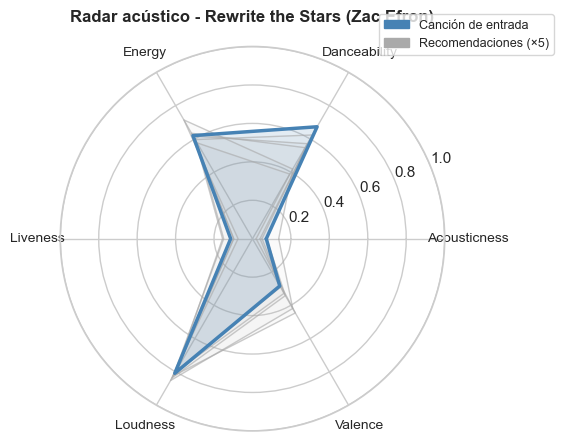

In [13]:
plot_radar(
    feats_3, recs_3,
    titulo='Radar acústico - Rewrite the Stars (Zac Efron)',
    savepath='figuras/Cualitativo/radar_rewrite_the_stars.png'
)

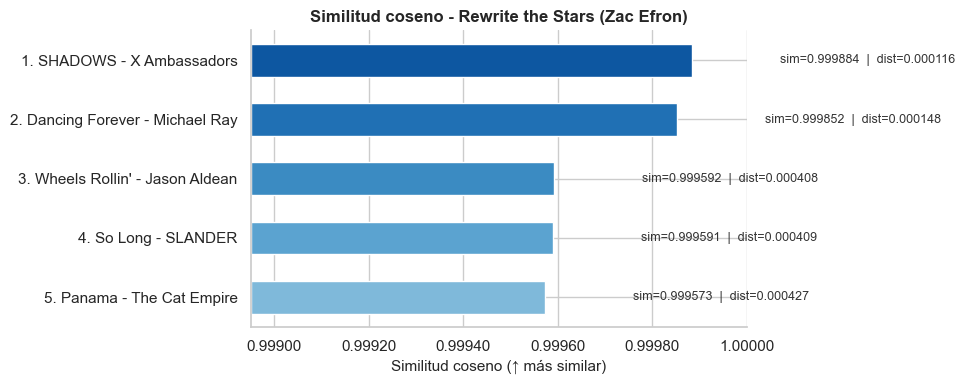

In [14]:
plot_similitudes(
    recs_3,
    titulo='Similitud coseno - Rewrite the Stars (Zac Efron)',
    savepath='figuras/Cualitativo/dist_rewrite_the_stars.png'
)

**Interpretación:**

Las similitudes coseno se encuentran entre **0.999573 y 0.999884**, con distancias de **0.000116–0.000427**. La cohesión (0.000301) es la más alta de los tres casos del catálogo, indicando que esta canción ocupa una zona del espacio PCA algo menos densa.

Las características clave del vecindario son:

- **danceability**: la entrada tiene `danceability = 0.673`; las recomendaciones van de 0.388 a 0.623. Es el eje con mayor variación del vecindario, visible en el radar como el punto de mayor divergencia entre recomendaciones.
- **energy**: `0.620` en la entrada; el vecindario oscila entre 0.576 y 0.714, con mayor dispersión que en los casos anteriores.
- **valence**: `0.284` en la entrada; todas las recomendaciones están en la zona oscura (0.291–0.446), lo que sugiere que `valence` actúa como filtro efectivo en esta región del espacio.
- **acousticness**: baja pero no nula (0.020–0.137), al igual que la entrada (0.072).

La mayor dispersión del vecindario en `danceability` y `energy` respecto a los casos anteriores explica la cohesión algo menor, y es coherente con que la combinación danceability media-alta + valence baja es menos frecuente en el catálogo.

Desde mi apreciación personal, las recomendaciones son **moderadamente coherentes**. **SHADOWS (X Ambassadors)** es indie rock con carga dramática, y la siento como la recomendación más acertada: energía media, oscura, similar en sensación a *Rewrite the Stars*. **So Long (SLANDER)** es EDM melancólico, y aunque es un género muy distinto, el carácter oscuro y bailable coincide bastante. **Dancing Forever (Michael Ray)** y **Wheels Rollin' (Jason Aldean)** son country pop, géneros alejados del pop cinematográfico de la película *The Greatest Showman*, pero métricamente en rango. **Panama (The Cat Empire)** me resulta la más discutible: es la más lejana del vecindario (dist = 0.000427) y su `valence` (0.446) y `danceability` (0.388) se alejan más de la entrada que el resto.

### **5.4 Análisis comparativo transversal**

Una vez examinados los tres casos individualmente, esta sección los compara entre sí para extraer conclusiones sobre el comportamiento global del modelo.

In [15]:
# Cohesión y diversidad individual vs. global del modelo
COHESION_GLOBAL  = 0.0014   # valor obtenido en la evaluación del Notebook 4
DIVERSIDAD_GLOBAL = 0.0023

filas = []
for nombre, idx in [('Smells Like Teen Spirit', idx_1),
                    ('The Climb',               idx_2),
                    ('Rewrite the Stars',       idx_3)]:
    c, d = calcular_cohesion_diversidad(idx)
    filas.append({
        'Canción'           : nombre,
        'Cohesión'          : round(c, 6),
        'Diversidad'        : round(d, 6),
        'Δ Cohesión (global)': round(c - COHESION_GLOBAL, 6),
    })

df_resumen = pd.DataFrame(filas)

# Fila global para referencia
df_resumen.loc[len(df_resumen)] = {
    'Canción'            : '- Media global del modelo -',
    'Cohesión'           : COHESION_GLOBAL,
    'Diversidad'         : DIVERSIDAD_GLOBAL,
    'Δ Cohesión (global)': 0.0,
}

print("Cohesión y diversidad por caso (distancia coseno en espacio PCA):")
print("  Cohesión  ↓ mejor  |  Diversidad ↑ mejor\n")
display(df_resumen.style.format({
    'Cohesión'           : '{:.6f}',
    'Diversidad'         : '{:.6f}',
    'Δ Cohesión (global)': '{:+.6f}'
}).hide(axis='index'))

Cohesión y diversidad por caso (distancia coseno en espacio PCA):
  Cohesión  ↓ mejor  |  Diversidad ↑ mejor



Canción,Cohesión,Diversidad,Δ Cohesión (global)
Smells Like Teen Spirit,0.000190,0.000459,-0.001210
The Climb,0.000218,0.000302,-0.001182
Rewrite the Stars,0.000301,0.000338,-0.001099
- Media global del modelo -,0.001400,0.002300,+0.000000


#### **Proyección de los vecindarios en el espacio PCA (PC1 vs PC2)**

Las dos primeras componentes principales permiten visualizar dónde se sitúan las canciones analizadas dentro del espacio del catálogo y si sus vecindarios están bien agrupados.

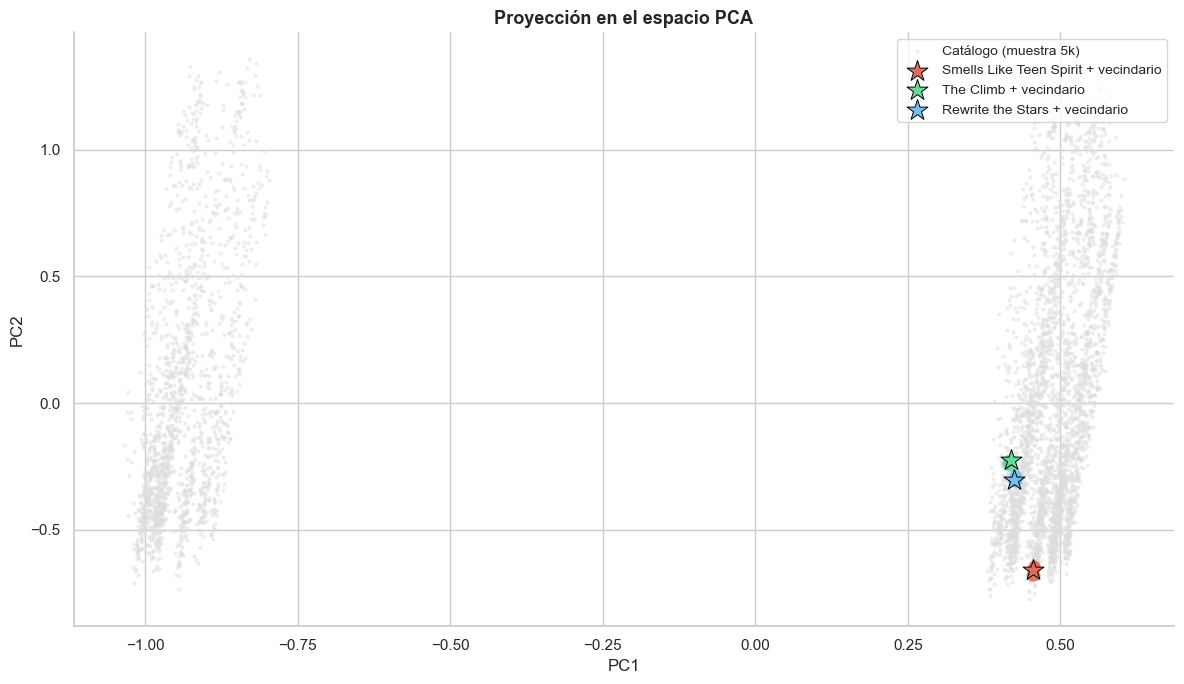

In [16]:
# Muestra aleatoria del catálogo para el fondo del scatter
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_pca), size=5000, replace=False)
X_sample   = X_pca[sample_idx]

# Índices de las recomendaciones de cada canción
def get_top_idx(idx, k=5):
    vec   = X_pca[idx].reshape(1, -1)
    dists = cosine_distances(vec, X_pca)[0]
    dists[idx] = np.inf
    return np.argsort(dists)[:k]

top1 = get_top_idx(idx_1)
top2 = get_top_idx(idx_2)
top3 = get_top_idx(idx_3)

# Colores por caso
colores_caso = {
    'Smells Like Teen Spirit': "#dd6e62",   # rojo
    'The Climb'              : "#69db99",   # verde
    'Rewrite the Stars'      : "#75bded",   # azul
}

fig, ax = plt.subplots(figsize=(12, 7))

# Fondo: nube del catálogo
ax.scatter(X_sample[:, 0], X_sample[:, 1],
           c='#dddddd', s=4, alpha=0.4, zorder=1, label='Catálogo (muestra 5k)')

# Vecindarios y entradas por caso
for (nombre, idx_e, top_idx) in [
    ('Smells Like Teen Spirit', idx_1, top1),
    ('The Climb',               idx_2, top2),
    ('Rewrite the Stars',       idx_3, top3),
]:
    color = colores_caso[nombre]
    # Recomendaciones
    ax.scatter(X_pca[top_idx, 0], X_pca[top_idx, 1],
               c=color, s=60, alpha=0.7, zorder=3)
    # Canción de entrada (estrella)
    ax.scatter(X_pca[idx_e, 0], X_pca[idx_e, 1],
               c=color, s=250, marker='*', edgecolors='black',
               linewidths=0.7, zorder=5, label=f'{nombre} + vecindario')

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('Proyección en el espacio PCA', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
sns.despine()
plt.tight_layout()
plt.savefig('figuras/Cualitativo/pca_scatter_vecindarios.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación transversal:**

La tabla de métricas confirma que los tres casos obtienen cohesiones muy inferiores a la media global del modelo (0.0014), con valores de 0.000190, 0.000218 y 0.000301. El caso más cohesionado es *Smells Like Teen Spirit* (0.000190), seguido de *The Climb* (0.000218), y el más disperso es *Rewrite the Stars* (0.000301), coherente con que su combinación de `danceability` media-alta y `valence` baja es menos frecuente en el catálogo que los perfiles de los otros dos casos.

La proyección sobre PC1 y PC2 permite situar visualmente los tres vecindarios en el espacio reducido. Conviene aclarar que **PC1 y PC2 no son características acústicas concretas**: son combinaciones lineales de las 24 dimensiones originales construidas por el PCA, por lo que sus ejes no tienen una interpretación musical directa. Lo que sí se puede observar en el scatter es que los tres vecindarios aparecen en zonas distintas del plano, sin solapamiento entre ellos, y que *The Climb* y *Rewrite the Stars* están algo más próximas entre sí que cualquiera de las dos respecto a *Smells Like Teen Spirit*. Esto es coherente con sus perfiles: las dos primeras comparten `energy` media y `acousticness` baja, mientras que *Smells Like Teen Spirit* tiene `energy` y `loudness` muy superiores.

Respecto a la diversidad, los tres casos están también por debajo de la media global (0.0023), con valores de 0.000459, 0.000302 y 0.000338. La diversidad más alta la presenta *Smells Like Teen Spirit* (0.000459): aunque todas sus recomendaciones tienen `energy` alta, otras características como `danceability` (0.415–0.558) o `valence` (0.665–0.741) varían más entre ellas. La diversidad más baja corresponde a *The Climb* (0.000302), cuyo vecindario es el más homogéneo en todas las dimensiones.

### **5.5 Análisis del módulo OOV**

El módulo OOV desarrollado en el Notebook 3 permite recomendar canciones que **no pertenecen al catálogo**, extrayendo sus características acústicas mediante DSP a partir de un preview de audio de 30 segundos obtenido de iTunes. Esta sección evalúa su comportamiento en dos escenarios complementarios:

1. **Canción del catálogo procesada como OOV:** se toma *The Climb* (Miley Cyrus), cuyo vector real es conocido, se procesa su audio con el pipeline DSP y se comparan ambos vectores. Esto permite cuantificar empíricamente la degradación introducida por la extracción heurística.
2. **Canción genuinamente OOV:** se analiza *Easy On Me* (Adele, 2021), una balada acústica que no figura en el catálogo por ser posterior al periodo de recopilación de los datasets originales.

> **Nota de reproducibilidad:** las celdas de extracción OOV (descarga de audio + DSP) requieren credenciales de Spotify en el archivo `.env` y conexión a internet. Los vectores extraídos se muestran como resultado de la ejecución real y se almacenan para el análisis posterior.

In [17]:
# Importación de las librerías necesarias para el módulo OOV
# (las mismas que se usaron en el Notebook 3)
import requests
import urllib.parse

import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import librosa
from pydub import AudioSegment
from dotenv import load_dotenv

os.makedirs('temp_audio', exist_ok=True)

load_dotenv()
CLIENT_ID     = os.getenv('SPOTIPY_CLIENT_ID')
CLIENT_SECRET = os.getenv('SPOTIPY_CLIENT_SECRET')

auth_manager = SpotifyClientCredentials(client_id=CLIENT_ID, client_secret=CLIENT_SECRET)
sp = spotipy.Spotify(auth_manager=auth_manager)
print("✅ Autenticación con Spotify correcta.")

✅ Autenticación con Spotify correcta.


In [18]:
# Funciones del pipeline OOV (extraídas del Notebook 3)

def obtener_metadatos_spotify(query):
    resultados = sp.search(q=query, type='track', limit=1)
    if not resultados['tracks']['items']:
        return None
    track       = resultados['tracks']['items'][0]
    cover_url   = track['album']['images'][0]['url'] if track['album']['images'] else None
    return {
        'track_id'    : track['id'],
        'track_name'  : track['name'],
        'artist_name' : track['artists'][0]['name'],
        'cover_url'   : cover_url,
        'duration_ms' : track['duration_ms'],
    }


def descargar_audio_itunes(artist_name, track_name, track_id, folder='temp_audio'):
    file_path    = f"{folder}/{track_id}.m4a"
    query_enc    = urllib.parse.quote(f"{artist_name} {track_name}")
    response     = requests.get(f"https://itunes.apple.com/search?term={query_enc}&entity=song&limit=1")
    if response.status_code == 200:
        data = response.json()
        if data['resultCount'] > 0:
            preview_url = data['results'][0].get('previewUrl')
            if preview_url:
                with open(file_path, 'wb') as f:
                    f.write(requests.get(preview_url).content)
                return file_path
    return None


def convertir_a_wav(ruta_m4a):
    ruta_wav = ruta_m4a.replace('.m4a', '.wav')
    AudioSegment.from_file(ruta_m4a, format='m4a').export(ruta_wav, format='wav')
    return ruta_wav


def extraer_caracteristicas_acusticas(ruta_wav, duracion_real_ms):
    """
    Aproximación heurística de las métricas de audio de Spotify mediante DSP.
    Implementación idéntica a la del módulo backend/oov_processor.py y al Notebook 3.
    """
    try:
        # Carga doble: raw para RMS real, normalizado para análisis espectral
        y_raw, sr = librosa.load(str(ruta_wav), sr=22050)
        y = librosa.util.normalize(y_raw)

        features = {}
        features['duration_ms'] = float(duracion_real_ms)

        # 1. Loudness y Energy
        rms_frames = librosa.feature.rms(y=y_raw)[0]
        rms_mean   = np.mean(rms_frames)
        db_mean    = np.mean(librosa.amplitude_to_db(rms_frames, ref=1.0))
        features['loudness'] = float(np.clip((db_mean + 30) / 20, 0.0, 1.0))
        p95 = np.percentile(rms_frames, 95)
        features['energy']   = float(np.clip(rms_mean / (p95 + 1e-6), 0.0, 1.0))

        # 2. HPSS
        y_harmonic, y_percussive = librosa.effects.hpss(y)
        harm_rms   = np.mean(librosa.feature.rms(y=y_harmonic))
        perc_rms   = np.mean(librosa.feature.rms(y=y_percussive))
        harm_ratio = harm_rms / (harm_rms + perc_rms + 1e-6)

        # 3. Tempo
        onset_env = librosa.onset.onset_strength(y=y_harmonic, sr=sr, aggregate=np.median)
        tempo_val = float(librosa.feature.tempo(onset_envelope=onset_env, sr=sr)[0])
        if tempo_val > 145:
            tempo_val /= 2.0
        features['tempo'] = tempo_val

        # 4. Danceability
        bpm_score  = np.exp(-((tempo_val - 120.0)**2) / (2 * 40.0**2))
        beat_score = min(1.0, np.std(onset_env) / 2.5)
        features['danceability'] = float(bpm_score * 0.5 + beat_score * 0.5)

        # 5. Acousticness
        rolloff      = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
        rolloff_norm = np.mean(rolloff) / (sr / 2)
        features['acousticness'] = float(np.clip(
            (1 - rolloff_norm) * 0.7 + harm_ratio * 0.3, 0.0, 1.0
        ))

        # 6. Speechiness
        mfcc       = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_delta = librosa.feature.delta(mfcc)
        vocal_variance = np.mean(np.var(mfcc_delta[:4, :], axis=1))
        features['speechiness'] = float(np.clip(vocal_variance / 150.0, 0.0, 1.0))

        # 7. Instrumentalness
        if features['speechiness'] > 0.15:
            features['instrumentalness'] = float(np.clip(
                0.05 * (1.0 - features['speechiness']), 0.0, 1.0
            ))
        else:
            features['instrumentalness'] = float(np.clip(
                1.0 - (features['speechiness'] / 0.15), 0.0, 1.0
            ))

        # 8. Liveness
        flatness = librosa.feature.spectral_flatness(y=y)
        features['liveness'] = float(np.mean(flatness) * 25)

        # 9. Key y Mode (Krumhansl-Schmuckler)
        chroma      = librosa.feature.chroma_stft(y=y_harmonic, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        mayor = np.array([6.35,2.23,3.48,2.33,4.38,4.09,2.52,5.19,2.39,3.66,2.29,2.88])
        menor = np.array([6.33,2.68,3.52,5.38,2.60,3.53,2.54,4.75,3.98,2.69,3.34,3.17])
        notas = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
        corr_mayor = [np.corrcoef(np.roll(mayor, i), chroma_mean)[0,1] for i in range(12)]
        corr_menor = [np.corrcoef(np.roll(menor, i), chroma_mean)[0,1] for i in range(12)]
        if max(corr_mayor) >= max(corr_menor):
            features['key']  = notas[np.argmax(corr_mayor)]
            features['mode'] = 'Major'
        else:
            features['key']  = notas[np.argmax(corr_menor)]
            features['mode'] = 'Minor'

        # 10. Valence
        mode_score  = 0.65 if features['mode'] == 'Major' else 0.35
        tempo_score = float(np.clip((tempo_val - 60) / 140, 0.0, 1.0))
        features['valence'] = float(np.clip(
            mode_score * 0.5 + features['energy'] * 0.3 + tempo_score * 0.2,
            0.0, 1.0
        ))

        # Garantizar rango [0, 1] en todas las características probabilísticas
        for col in ['energy','acousticness','danceability','speechiness',
                    'valence','instrumentalness','liveness','loudness']:
            features[col] = float(np.clip(features.get(col, 0.5), 0.0, 1.0))

        return features

    except Exception as e:
        print(f"❌ Error al extraer características con librosa: {e}")
        return None


def procesar_pipeline_oov(features_dict):
    df_oov      = pd.DataFrame([features_dict])
    encoded_raw = encoder.transform(df_oov[cat_cols])
    encoded_arr = encoded_raw.toarray() if hasattr(encoded_raw, 'toarray') else encoded_raw
    df_encoded  = pd.DataFrame(encoded_arr, columns=encoder.get_feature_names_out(cat_cols))
    scaled_nums = np.clip(scaler.transform(df_oov[num_cols]), 0.0, 1.0)
    df_scaled   = pd.DataFrame(scaled_nums, columns=num_cols)
    return pd.concat([df_scaled, df_encoded], axis=1)


def recomendar_oov(vector_df, k=5):
    """
    Dado un DataFrame de 1 fila con el vector procesado (24 dims),
    aplica PCA y devuelve las K recomendaciones más cercanas.
    """
    X_oov   = pca.transform(vector_df.values)
    dists   = cosine_distances(X_oov, X_pca)[0]
    top_idx = np.argsort(dists)[:k]
    rows = []
    for rank, ti in enumerate(top_idx, start=1):
        rows.append({
            'rank'        : rank,
            'track_name'  : meta.iloc[ti]['track_name'],
            'artist_name' : meta.iloc[ti]['artist_name'],
            'popularity'  : meta.iloc[ti]['popularity'],
            'cosine_sim'  : round(1 - dists[ti], 6),
            'cosine_dist' : round(dists[ti], 6),
            **{col: round(df.iloc[ti][col], 4) for col in num_cols}
        })
    return pd.DataFrame(rows)


print("✅ Pipeline OOV cargado correctamente.")

✅ Pipeline OOV cargado correctamente.


#### **Experimento 1 - Canción del catálogo procesada como OOV: The Climb (Miley Cyrus)**

Se extrae el audio de *The Climb* mediante el pipeline OOV y se compara el vector DSP resultante con el vector real almacenado en el catálogo. El objetivo es **cuantificar la degradación** introducida por la extracción heurística antes de observar su impacto en las recomendaciones.

In [19]:
# Ejecución del pipeline OOV para The Climb
query_oov1 = "The Climb Miley Cyrus"

print(f"🔍 Buscando: '{query_oov1}'...")
metadatos_oov1 = obtener_metadatos_spotify(query_oov1)
print(f"✅ Metadatos: {metadatos_oov1['track_name']} - {metadatos_oov1['artist_name']}")

print("⬇️  Descargando preview iTunes...")
ruta_m4a_oov1 = descargar_audio_itunes(
    metadatos_oov1['artist_name'], metadatos_oov1['track_name'],
    metadatos_oov1['track_id']
)

print("🔄 Convirtiendo a WAV...")
ruta_wav_oov1 = convertir_a_wav(ruta_m4a_oov1)

print("⚙️  Extrayendo características con Librosa...")
features_oov1 = extraer_caracteristicas_acusticas(ruta_wav_oov1, metadatos_oov1['duration_ms'])

print("\n✅ Características extraídas (DSP):")
for k_feat, v in features_oov1.items():
    print(f"   {k_feat}: {round(v, 4) if isinstance(v, float) else v}")

🔍 Buscando: 'The Climb Miley Cyrus'...
✅ Metadatos: The Climb - Miley Cyrus
⬇️  Descargando preview iTunes...
🔄 Convirtiendo a WAV...
⚙️  Extrayendo características con Librosa...

✅ Características extraídas (DSP):
   duration_ms: 234520.0
   loudness: 0.6977
   energy: 0.7491
   tempo: 80.7495
   danceability: 0.404
   acousticness: 0.6175
   speechiness: 0.1074
   instrumentalness: 0.2837
   liveness: 0.3256
   key: E
   mode: Major
   valence: 0.5794


In [20]:
# Comparación vector REAL vs. vector DSP para The Climb
feats_reales_oov1 = df.loc[idx_2, num_cols].to_dict()  # idx_2 = The Climb en el catálogo

# Vectorizar el resultado DSP
vector_oov1 = procesar_pipeline_oov(features_oov1)

# Construir tabla comparativa (solo features numéricas interpretables)
feats_dsp_oov1 = {col: round(vector_oov1[col].values[0], 4) for col in num_cols}

df_comparacion = pd.DataFrame({
    'Característica' : num_cols,
    'Vector REAL'    : [round(feats_reales_oov1[c], 4) for c in num_cols],
    'Vector DSP'     : [feats_dsp_oov1[c] for c in num_cols],
})
df_comparacion['Δ (DSP − Real)'] = (
    df_comparacion['Vector DSP'] - df_comparacion['Vector REAL']
).round(4)

mae_oov1 = df_comparacion['Δ (DSP − Real)'].abs().mean()

print("Comparación vector real vs. vector extraído por DSP - The Climb (Miley Cyrus):")
print(f"MAE global: {mae_oov1:.4f}\n")
display(df_comparacion.style.format({
    'Vector REAL'    : '{:.4f}',
    'Vector DSP'     : '{:.4f}',
    'Δ (DSP − Real)' : '{:+.4f}'
}).bar(subset=['Δ (DSP − Real)'], align='mid', color=['#f1948a', '#82e0aa']).hide(axis='index'))

Comparación vector real vs. vector extraído por DSP - The Climb (Miley Cyrus):
MAE global: 0.2127



Característica,Vector REAL,Vector DSP,Δ (DSP − Real)
acousticness,0.0837,0.6200,+0.5363
danceability,0.2897,0.3723,+0.0826
duration_ms,0.3615,0.3588,-0.0027
energy,0.5886,0.7498,+0.1612
instrumentalness,0.0000,0.2840,+0.2840
liveness,0.0953,0.3190,+0.2237
loudness,0.8158,0.9458,+0.1300
speechiness,0.0121,0.0902,+0.0781
tempo,0.6150,0.2370,-0.3780
valence,0.3290,0.5794,+0.2504


In [21]:
# Recomendaciones con vector REAL (referencia) vs. vector DSP
print("Recomendaciones con vector REAL (referencia del catálogo):")
_, _, recs_real_oov1, _ = recomendar('0V8FYVlBFuXXTIvRnMbZyS')
display(recs_real_oov1[['rank','track_name','artist_name','cosine_sim','cosine_dist',
                          'acousticness','danceability','energy','loudness','liveness','valence']])

print()
print("Recomendaciones con vector DSP (pipeline OOV):")
recs_dsp_oov1 = recomendar_oov(vector_oov1)
display(recs_dsp_oov1[['rank','track_name','artist_name','cosine_sim','cosine_dist',
                         'acousticness','danceability','energy','loudness','liveness','valence']])

Recomendaciones con vector REAL (referencia del catálogo):


,rank,track_name,artist_name,cosine_sim,cosine_dist,acousticness,danceability,energy,loudness,liveness,valence
0,1,Love Never Fails,Israel Houghton,0.999916,0.000084,0.1014,0.3648,0.6156,0.8102,0.0748,0.314
1,2,Always,Bon Jovi,0.999812,0.000188,0.1175,0.3498,0.6597,0.8345,0.0688,0.327
2,3,Changed,Rascal Flatts,0.999747,0.000253,0.0787,0.4142,0.5596,0.8143,0.0899,0.291
3,4,I Almost Do,Taylor Swift,0.999720,0.000280,0.0204,0.5461,0.4845,0.8054,0.1629,0.220
4,5,Radar Love - Original Single Edit 1973,Golden Earring,0.999713,0.000287,0.0118,0.4678,0.5826,0.6734,0.1175,0.249



Recomendaciones con vector DSP (pipeline OOV):


,rank,track_name,artist_name,cosine_sim,cosine_dist,acousticness,danceability,energy,loudness,liveness,valence
0,1,I Got A Line On You,Spirit,0.978599,0.021401,0.3795,0.4067,0.6156,0.7845,0.4951,0.757
1,2,Gravity Rides Everything,Modest Mouse,0.975967,0.024033,0.4327,0.3627,0.4434,0.7915,0.4992,0.714
2,3,Sugar Babe,Steve Miller Band,0.974198,0.025802,0.5120,0.3916,0.6937,0.7885,0.3628,0.479
3,4,Smoke Big Factory - Remastered,The Guess Who,0.973821,0.026179,0.4548,0.3391,0.4675,0.7049,0.2508,0.721
4,5,Suddenly,Drugdealer,0.970077,0.029923,0.5050,0.6373,0.4655,0.7993,0.4901,0.585


**Interpretación:**

La tabla comparativa muestra el vector real de *The Climb* en el catálogo frente al vector extraído por el pipeline DSP. El MAE global obtenido es **0.2127**, superior al MAE medio global de 0.165 documentado en la validación del módulo (sección 3.3 del Capítulo IV), lo que indica que *The Climb* resulta un caso especialmente desfavorable para el pipeline. Los sesgos más pronunciados son:

- **acousticness**: Δ = +0.536 (de 0.084 a 0.618). Es el error más grave y el más llamativo respecto a la validación, donde esta característica obtuvo un MAE de 0.094, considerado "bueno". La diferencia refleja la variabilidad del módulo: la fórmula DSP basada en rolloff espectral y ratio armónico funciona bien en canciones con perfil acústico claro (como las canciones de validación), pero sobreestima la componente acústica en canciones con instrumentación mixta sobre un clip de 30 segundos.
- **tempo**: Δ = −0.378 (de 0.615 a 0.237). El algoritmo de detección de beat estima un tempo equivocado sobre el fragmento de 30 segundos, probablemente por confusión entre el pulso principal y alguna subdivisión del compás. En la validación esta característica tuvo MAE de 0.100; *The Climb* representa un caso fuera de ese rango habitual.
- **valence**: Δ = +0.250 (de 0.329 a 0.579). La fórmula de valence DSP, basada en mode y energy, devuelve un valor más neutro-positivo que no captura el carácter melancólico de la canción. Este comportamiento es consistente con la validación, donde valence obtuvo el segundo MAE más alto (0.250) y fue catalogada como "limitación documentada".
- **liveness**: Δ = +0.224 (de 0.095 a 0.319), sobreestimado por el cálculo de flatness espectral sobre el clip.
- **instrumentalness**: Δ = +0.284 (de 0.000 a 0.284), resultado derivado de la estimación de speechiness, en línea con la validación donde instrumentalness presentó el MAE más alto (0.351).
- **energy**: Δ = +0.161 (de 0.589 a 0.750), inflado por la normalización Sound Check de iTunes y el cálculo por percentil 95.
- **loudness**: Δ = +0.130 (de 0.816 a 0.946), elevado sistemáticamente por la normalización Sound Check, sesgo ya documentado en la sección 3.3.

El impacto en las recomendaciones es total y muy visible. Con el **vector real**, el modelo recupera canciones del ámbito del pop emocional e inspiracional con `energy` entre 0.485 y 0.660, `acousticness` entre 0.012 y 0.199 y `valence` entre 0.220 y 0.327, coherentes con el perfil de *The Climb*. Con el **vector DSP**, los sesgos acumulados en `acousticness`, `liveness` y `energy` sitúan la canción en una zona del espacio PCA completamente distinta: las recomendaciones cambian a canciones de `acousticness` media-alta y `liveness` elevada como *I Got A Line On You* (Spirit, `acousticness = 0.380`, `liveness = 0.495`), *Gravity Rides Everything* (Modest Mouse, `liveness = 0.499`) o *Sugar Babe* (Steve Miller Band, `acousticness = 0.512`). Las similitudes coseno caen de forma drástica: de 0.9997–0.9999 con el vector real a 0.970–0.978 con el vector DSP, reflejando que la canción ha sido desplazada a una zona mucho más alejada de su posición real. No hay ninguna canción en común entre las dos listas de cinco resultados.

Desde mi apreciación personal, las recomendaciones obtenidas con el vector DSP no tienen ningún sentido musical en relación con *The Climb*. Canciones como *I Got A Line On You* de Spirit o *Smoke Big Factory* de The Guess Who son rock clásico de los años 70 que no comparten el carácter emocional ni la sensación de la canción de entrada. Este experimento demuestra que el MAE de validación global (0.165) es una media que puede enmascarar errores mucho mayores en casos concretos: un MAE de 0.21 sobre una canción específica es suficiente para cambiar completamente el conjunto de recomendaciones y degradar severamente las similitudes coseno.

#### **Experimento 2 - Canción genuinamente OOV: Easy On Me (Adele)**

*Easy On Me* (Adele, 2021) es una balada de piano acústica que no figura en el catálogo por ser posterior al período de recopilación de los datasets originales. Su perfil acústico es bien conocido: `acousticness` muy alta, `energy` baja, `valence` reducida, lo que la hace comparable con el perfil de *The Climb* y permite valorar si el modelo reconoce esa similitud.

In [22]:
# Ejecución del pipeline OOV para Easy On Me
query_oov2 = "Easy On Me Adele"

print(f"🔍 Buscando: '{query_oov2}'...")
metadatos_oov2 = obtener_metadatos_spotify(query_oov2)
print(f"✅ Metadatos: {metadatos_oov2['track_name']} - {metadatos_oov2['artist_name']}")

print("⬇️  Descargando preview iTunes...")
ruta_m4a_oov2 = descargar_audio_itunes(
    metadatos_oov2['artist_name'], metadatos_oov2['track_name'],
    metadatos_oov2['track_id']
)

print("🔄 Convirtiendo a WAV...")
ruta_wav_oov2 = convertir_a_wav(ruta_m4a_oov2)

print("⚙️  Extrayendo características con Librosa...")
features_oov2 = extraer_caracteristicas_acusticas(ruta_wav_oov2, metadatos_oov2['duration_ms'])

print("\n✅ Características extraídas (DSP):")
for k_feat, v in features_oov2.items():
    print(f"   {k_feat}: {round(v, 4) if isinstance(v, float) else v}")

# Vectorizar
vector_oov2 = procesar_pipeline_oov(features_oov2)

🔍 Buscando: 'Easy On Me Adele'...
✅ Metadatos: Easy On Me - Adele
⬇️  Descargando preview iTunes...
🔄 Convirtiendo a WAV...
⚙️  Extrayendo características con Librosa...

✅ Características extraídas (DSP):
   duration_ms: 224694.0
   loudness: 0.8645
   energy: 0.7341
   tempo: 95.7031
   danceability: 0.521
   acousticness: 0.6056
   speechiness: 0.1918
   instrumentalness: 0.0404
   liveness: 0.1977
   key: F
   mode: Major
   valence: 0.5962


Recomendaciones para Easy On Me (Adele) - vector DSP


,rank,track_name,artist_name,popularity,cosine_sim,cosine_dist,acousticness,danceability,energy,loudness,liveness,valence
0,1,Classy Girls,The Lumineers,51,0.999036,0.000964,0.6637,0.7114,0.8028,0.7998,0.3416,0.497
1,2,Wildflower,Hank Crawford,35,0.998728,0.001272,0.5311,0.4657,0.6096,0.7824,0.4204,0.614
2,3,One of Us Must Know (Sooner or Later),Bob Dylan,42,0.998263,0.001737,0.5492,0.4013,0.6266,0.7651,0.3578,0.762
3,4,Mr. Blue Sky - 2012 Version,Electric Light Orchestra,51,0.997922,0.002078,0.6637,0.5644,0.6476,0.8374,0.4083,0.628
4,5,You Rascal You,Hanni El Khatib,46,0.997488,0.002512,0.4930,0.6009,0.6566,0.7906,0.0706,0.475


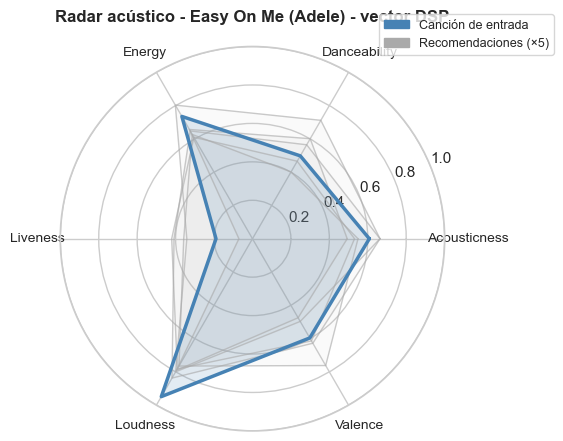

In [23]:
print("Recomendaciones para Easy On Me (Adele) - vector DSP")
recs_dsp_oov2 = recomendar_oov(vector_oov2)
display(recs_dsp_oov2[['rank','track_name','artist_name','popularity',
                         'cosine_sim','cosine_dist',
                         'acousticness','danceability','energy','loudness','liveness','valence']])

# Radar comparando Easy On Me (DSP) con sus recomendaciones
feats_oov2_series = pd.Series({
    col: round(vector_oov2[col].values[0], 4) for col in num_cols
})
plot_radar(
    feats_oov2_series, recs_dsp_oov2,
    titulo='Radar acústico - Easy On Me (Adele) - vector DSP',
    savepath='figuras/Cualitativo/radar_easy_on_me_oov.png'
)

**Interpretación:**

Los valores extraídos por el pipeline DSP para *Easy On Me* revelan sesgos significativos respecto al perfil real conocido de esta canción:

- **acousticness**: 0.606. *Easy On Me* es una balada de piano con `acousticness` real muy alta. El DSP extrae un valor intermedio (0.606) que se aleja bastante del valor real esperado, aunque no tan errático como en el Experimento 1.
- **energy**: 0.734. La canción real tiene una energía muy baja, propia de una balada lenta de piano. El valor extraído por DSP infla la energía considerablemente por efecto de la normalización Sound Check y el cálculo por percentil 95.
- **valence**: 0.596. *Easy On Me* es una canción claramente melancólica; el DSP devuelve un valor neutro-positivo que no captura su carga emocional negativa, al derivarse de `mode` (Major) y `energy`.
- **liveness**: 0.198. Valor más alto de lo esperado para una grabación de estudio.
- **loudness**: 0.865, elevado por la normalización Sound Check de iTunes.
- **key / mode**: F Major. La detección de tonalidad mediante Krumhansl-Schmuckler sobre el clip produce F Major, que puede ser correcta para el fragmento analizado aunque distinta de la tonalidad global oficial de la canción.

El resultado es que el modelo sitúa *Easy On Me* en una zona del espacio PCA de energía media-alta y acousticness intermedia, alejada de su posición real de balada acústica muy suave. Las recomendaciones obtenidas reflejan esto: *Classy Girls* de The Lumineers (`acousticness = 0.664`, `energy = 0.803`), *Mr. Blue Sky* de Electric Light Orchestra (`acousticness = 0.664`, `energy = 0.648`) o *One of Us Must Know* de Bob Dylan (`acousticness = 0.549`). Las similitudes coseno son también más bajas que las obtenidas en las canciones del catálogo (0.997–0.999 frente a 0.9997–0.9999), consecuencia del desplazamiento vectorial.

Desde mi apreciación personal, las recomendaciones presentan una coherencia parcial: algunas tienen componente acústica y carácter introspectivo (*One of Us Must Know* de Bob Dylan, *Wildflower* de Hank Crawford), pero otras como *Mr. Blue Sky* de ELO son canciones enérgicas y alegres que no se parecen en absoluto a *Easy On Me*. Comparando con el Experimento 1, el módulo se comporta algo mejor en este caso (las similitudes coseno son más altas y alguna recomendación tiene cierta coherencia), pero sigue sin capturar el perfil real de la canción.

### **5.6 Conclusiones del análisis cualitativo**

El análisis realizado sobre cinco casos de uso permite extraer las siguientes conclusiones sobre el comportamiento del modelo B1 - PCA + Similitud del Coseno:

**Sobre las canciones del catálogo:**

Los tres casos analizados obtienen cohesiones de vecindario (0.000190, 0.000218 y 0.000301) muy inferiores a la media global del modelo (0.0014), lo que confirma que los perfiles acústicos bien definidos generan vecindarios especialmente ajustados. Las características con mayor poder discriminante son `energy`, `acousticness` y `loudness`: en los tres casos, el vecindario queda fuertemente anclado en torno a los valores de la entrada en estas tres dimensiones, con muy poca variación entre recomendaciones. La `danceability` y la `valence` actúan como discriminantes secundarios, especialmente relevantes en zonas del espacio donde `energy` y `acousticness` no son suficientes para diferenciar candidatos.

Desde el punto de vista de la apreciación personal, los resultados son acertados en mayor o menor medida según el caso. *The Climb* obtiene las recomendaciones musicalmente más coherentes: todas las canciones sugeridas comparten el carácter emocional e inspiracional de la entrada, lo que indica que el modelo captura bien el perfil de balada emotiva cuando el espacio acústico correspondiente está bien representado en el catálogo. *Rewrite the Stars* obtiene recomendaciones moderadamente coherentes: algunas comparten la sensación oscura y bailable de la entrada, pero otras se alejan en términos de género y carácter. *Smells Like Teen Spirit* obtiene resultados parcialmente coherentes: tres de las cinco recomendaciones pertenecen a géneros cercanos al grunge (punk, post-grunge, hardcore), pero las otras dos (country pop e indie experimental) no comparten el carácter de Nirvana pese a ser métricamente similares.

Este comportamiento es una consecuencia estructural del modelo: al operar exclusivamente sobre descriptores acústicos, puede recomendar canciones de géneros completamente distintos si sus vectores de características son próximos en el espacio PCA. La ausencia de información sobre género, artista o contexto cultural es una limitación inherente a los sistemas de recomendación basados en contenido acústico.


**Sobre el módulo OOV:**

Los dos experimentos muestran que el pipeline DSP introduce sesgos que degradan la calidad de las recomendaciones, aunque con distinta intensidad según el caso. En el Experimento 1, procesando *The Climb* como OOV, se obtuvo un MAE global de 0.2127, con los errores más pronunciados en `acousticness` (Δ = +0.536), `tempo` (Δ = −0.378) y `valence` (Δ = +0.250). Este nivel de error desplaza la canción a una zona completamente diferente del espacio PCA: las similitudes coseno de las recomendaciones caen de 0.9997–0.9999 (vector real) a 0.970–0.978 (vector DSP), y ninguna de las cinco canciones sugeridas coincide con las del vector real ni tiene relación musical con *The Climb*. En el Experimento 2, con *Easy On Me* como canción genuinamente OOV, los sesgos en `energy`, `acousticness` y `valence` sitúan la canción en una zona de energía media-alta alejada de su perfil real de balada acústica. Las recomendaciones presentan una coherencia parcial: alguna tiene componente acústica e introspectiva, pero otras son ajenas al carácter de la canción. Las similitudes coseno (0.997–0.999) son más bajas que las del catálogo, aunque el degradado es menos severo que en el Experimento 1.

En ambos experimentos el módulo funciona correctamente como arquitectura (el pipeline de extracción, vectorización y búsqueda opera sin errores) pero la precisión de las recomendaciones queda limitada por la fidelidad de la extracción heurística mediante DSP. Las características más problemáticas son `acousticness`, `tempo`, `valence`, `liveness` y `energy`, que presentan los sesgos más altos y son a la vez algunas de las más determinantes en el cálculo de distancias coseno.
